# MIS 522 MANAGEMENT INFORMATION SYSTEM PRACTICUM

## ECONOMICS DATA ANALYSIS CASE

# STUDENT INSTRUCTIONS

---

## ⚠️ IMPORTANT SUBMISSION INFORMATION

**Submission Date:** 09 October 2026  
**Submission Time:** 7:00 PM onwards

**Submit To:**  
`sanjeevthapa@lcc.edu.np`

> **IMPORTANT:** This is a **STRICT SUBMISSION**.  
> Students must carefully follow **ALL instructions** given below.

---

# 1. OPEN THE COLAB NOTEBOOK

1. Open the **MIS_522 MIS EXAMS 5 Oct 2026.ipynb**.
2. Make your **own copy** of the notebook.
3. Use your own Google account while working.
4. Do **NOT** directly modify the original/shared notebook.
5. Rename your Colab notebook appropriately.
6. Read the instructions at the beginning of every section before running the code.

---

# 2. RUN EVERY CODE CELL

Students **MUST run the notebook from beginning to end**.

Follow this order:

### STEP 1
Run the first code cell.

### STEP 2
Check the output carefully.

### STEP 3
Read the explanation/instruction below the output.

### STEP 4
Check the **QUESTIONS** section.

### STEP 5
Write your answers separately in your handwritten answer sheet.

### STEP 6
Continue to the next code cell.

Repeat the same process for **ALL sections**.

---

## ⚠️ IMPORTANT

- **DO NOT SKIP CELLS.**
- **DO NOT RANDOMLY RUN CELLS.**
- **DO NOT ONLY RUN THE VISUALIZATION CELLS.**
- Run the notebook in the correct sequence.
- Check the output after each important cell.

The complete notebook should be executed in sequence so that the:

- Raw datasets
- Cleaned datasets
- Merged dataset
- Engineered variables
- Statistics
- Tables
- Visualizations

are generated correctly.

---

# 3. CHECK EVERY ANSWER SECTION

After each visualization or analysis section, there will be a **QUESTIONS** section.

Students **MUST check every question**.

### Example

**Q1. Which province has the highest median household income?**

**Q2. Which province shows the greatest income variation?**

**Q3. Are there any extreme income values?**

**Q4. Why is a boxplot useful for this analysis?**

**Q5. Why might average income alone be misleading?**

> ## IMPORTANT
> **Answer ALL questions.**
>
> Do **NOT** answer only selected questions.

---

# 4. ANSWERS MUST BE BASED ON YOUR OUTPUT

Your answers must be based on the results produced from **your own Colab notebook**.

For example:

If the graph shows that Province A has the highest median income, write **Province A** and explain the observation.

### DO NOT:

- Randomly guess the answer.
- Copy an answer from another student.
- Write generic answers without looking at the graph.
- Write an answer without checking the table/output.

### GOOD PRACTICE

First:

**Run → Check Output → Analyze → Answer**

---

---

# 5. 📱 SCANNING REQUIREMENT

After completing the handwritten answer sheet:

## SCAN THE COMPLETE ANSWER SHEET.

Use a scanning application such as:

- **CamScanner**
- **Adobe Scan**
- **Microsoft Lens**
- Any other proper document scanning application


---

# 6. FINAL FILE FORMAT

Submit the final scanned document as a **PDF**.

The filename **MUST** follow this format:

```text
YOUR NAME_MIS_SYMBOLNO.pdf


```example
Mohan Shrestha_MIS_1564K.pdf




---



---



---



---



# MIS 522 – MBA MIS Practicum
## Economics Case: National Household Cost-of-Living & Economic Burden Analysis

**Domain:** Economics / Business Economics / Management Decision Support  
  
**Platform:** Google Colab + Python

### CASE SCENARIO
Economic Insight Analytics Nepal (EIAN) has been hired to analyze household economic conditions.

The client provides two raw tables:

**TABLE 1 – Household Master:** exactly 3,000 original household records.

**TABLE 2 – Monthly Economic Observations:** exactly 8,000 original household-month observations.

The raw data are intentionally dirty. They contain NULL/missing values, duplicates, negative or invalid values, inconsistent category names, orphan IDs and outliers.

Your **job** is to act as an MIS analyst:




---


**RAW DATA → AUDIT → CLEAN → EDA → STATISTICS → MERGE → FEATURE ENGINEERING → VISUALIZATION → MANAGEMENT INSIGHTS**


---











### Student rule
1. Run each code cell, then answer the following Markdown question cell in copy handwritten.

2. Explain the business/economic meaning, not only the number.

# 1. Learning Objectives

By the end, students should be able to:

- inspect large datasets
- identify data-quality problems
- remove duplicates
- handle missing values
- detect invalid negative values
- normalize categories
- perform EDA
- calculate mean, median and mode
- produce summary statistics
- merge related tables
- perform feature engineering
- prepare data for Power BI
- design an interactive management dashboard
- communicate actionable economic insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded.")

Libraries loaded.


# GROUP QUESTIONS – 1
1. Why is Pandas useful for MIS data analysis?
2. Why do we use NumPy?
3. Why are visualizations important for managers?
4. Why is reproducibility important when creating a teaching dataset?


Answer 1
==========================






===========================

# 2. CREATE TABLE 1 – HOUSEHOLD MASTER

The original table contains exactly 3,000 households. Problems are deliberately inserted.

In [8]:
N = 3000
ids = [f"HH{100001+i}" for i in range(N)]

provinces = ["Koshi","Madhesh","Bagmati","Gandaki","Lumbini","Karnali","Sudurpashchim"]
t1 = pd.DataFrame({
    "Household_ID": ids,
    "Province": np.random.choice(provinces,N,p=[.13,.16,.24,.12,.18,.07,.10]),
    "Area_Type": np.random.choice(["Urban","Rural"],N,p=[.58,.42]),
    "Employment_Status": np.random.choice(["Employed","Self-Employed","Informal","Unemployed"],N,p=[.43,.27,.20,.10]),
    "Education": np.random.choice(["Primary","Secondary","Bachelor","Master+"],N,p=[.17,.38,.30,.15]),
    "Household_Size": np.random.randint(1,9,N),
    "Monthly_Income": np.clip(np.random.lognormal(np.log(65000),.48,N),15000,500000).round(0)
})

# Intentional problems
t1.loc[np.random.choice(N,80,False),"Monthly_Income"] = np.nan
t1.loc[np.random.choice(N,55,False),"Employment_Status"] = np.nan
t1.loc[np.random.choice(N,35,False),"Education"] = np.nan

idx=np.random.choice(N,20,False)
t1.loc[idx,"Monthly_Income"]=-np.random.randint(1000,30000,20)
idx=np.random.choice(N,12,False)
t1.loc[idx,"Household_Size"]=-np.random.randint(1,4,12)

idx=np.random.choice(N,100,False)
t1.loc[idx[:35],"Area_Type"]="urban"
t1.loc[idx[35:70],"Area_Type"]=" URBAN "
t1.loc[idx[70:],"Area_Type"]="rural"

idx=np.random.choice(N,100,False)
t1.loc[idx[:30],"Province"]="Bagmati Province"
t1.loc[idx[30:60],"Province"]="bagmati"
t1.loc[idx[60:],"Province"]=" BAGMATI "

table1_raw=pd.concat([t1,t1.sample(25,random_state=10)],ignore_index=True)

print("TABLE 1 RAW SHAPE:",table1_raw.shape)
print("Original household count: 3,000")
display(table1_raw.head())






TABLE 1 RAW SHAPE: (3025, 7)
Original household count: 3,000


,Household_ID,Province,Area_Type,Employment_Status,Education,Household_Size,Monthly_Income
0,HH100001,Bagmati,Urban,Employed,NaN,2,"87,218.00"
1,HH100002,Lumbini,Rural,Self-Employed,Bachelor,3,"142,577.00"
2,HH100003,Bagmati,Urban,Informal,Secondary,4,"31,015.00"
3,HH100004,Karnali,Rural,Self-Employed,Primary,7,"74,196.00"
4,HH100005,Koshi,Urban,Informal,Bachelor,6,"48,017.00"


In [11]:



table1_raw








,Household_ID,Province,Area_Type,Employment_Status,Education,Household_Size,Monthly_Income
0,HH100001,Bagmati,Urban,Employed,NaN,2,"87,218.00"
1,HH100002,Lumbini,Rural,Self-Employed,Bachelor,3,"142,577.00"
2,HH100003,Bagmati,Urban,Informal,Secondary,4,"31,015.00"
3,HH100004,Karnali,Rural,Self-Employed,Primary,7,"74,196.00"
4,HH100005,Koshi,Urban,Informal,Bachelor,6,"48,017.00"
...,...,...,...,...,...,...,...
3020,HH100109,Bagmati,Rural,Informal,Master+,2,"65,267.00"
3021,HH101332,Gandaki,Urban,Self-Employed,Primary,5,"99,484.00"
3022,HH100283,Koshi,Urban,Informal,Bachelor,7,"62,349.00"
3023,HH101199,Madhesh,Urban,Self-Employed,Primary,7,"59,555.00"


In [12]:



from google.colab import sheets
sheet = sheets.InteractiveSheet(df=table1_raw)






https://docs.google.com/spreadsheets/d/1ip8d-jkGzSwgBFqWVzszMhcBK8esM3d2fBthdJzqCVU/edit#gid=0


# GROUP QUESTIONS – 2: TABLE 1
1. Why are there more than 3,000 rows?
2. Which variables contain NULL values?
3. Which values are logically invalid?
4. Why is negative income a data-quality problem?
5. Why can inconsistent province spelling affect reports and dashboards?


Answer 2
==========================





....
===========================

# 3. CREATE TABLE 2 – MONTHLY ECONOMIC OBSERVATIONS

The original table contains exactly 8,000 observations.

In [13]:
N2=8000
months=pd.date_range("2024-01-01","2025-12-01",freq="MS")

table2=pd.DataFrame({
    "Household_ID":np.random.choice(t1["Household_ID"],N2),
    "Observation_Month":np.random.choice(months,N2),
    "Inflation_Rate":np.random.normal(6.2,1.1,N2).round(2),
    "Food_Inflation":np.random.normal(7.4,1.4,N2).round(2),
    "Interest_Rate":np.random.normal(7.5,.7,N2).round(2),
    "Essential_Expenditure":np.random.lognormal(np.log(22000),.35,N2).round(0),
    "Discretionary_Expenditure":np.random.lognormal(np.log(12000),.45,N2).round(0),
    "Employment_Index":np.random.normal(92,3,N2).round(2)
})

# Intentional NULLs
table2.loc[np.random.choice(N2,120,False),"Inflation_Rate"]=np.nan
table2.loc[np.random.choice(N2,100,False),"Essential_Expenditure"]=np.nan
table2.loc[np.random.choice(N2,70,False),"Discretionary_Expenditure"]=np.nan

# Intentional negatives
idx=np.random.choice(N2,25,False)
table2.loc[idx[:10],"Essential_Expenditure"]=-np.random.randint(500,10000,10)
table2.loc[idx[10:18],"Discretionary_Expenditure"]=-np.random.randint(500,8000,8)
table2.loc[idx[18:],"Inflation_Rate"]=-np.random.uniform(1,5,7)
table2.loc[np.random.choice(N2,8,False),"Interest_Rate"]=-2.5

# Extreme values
idx=np.random.choice(N2,30,False)
table2.loc[idx,"Essential_Expenditure"]*=8

# Orphan IDs
idx=np.random.choice(N2,30,False)
table2.loc[idx,"Household_ID"]=[f"HH{900000+i}" for i in range(len(idx))]

table2_raw=pd.concat([table2,table2.sample(40,random_state=20)],ignore_index=True)

print("TABLE 2 RAW SHAPE:",table2_raw.shape)
print("Original observation count: 8,000")
display(table2_raw.head())

TABLE 2 RAW SHAPE: (8040, 8)
Original observation count: 8,000


,Household_ID,Observation_Month,Inflation_Rate,Food_Inflation,Interest_Rate,Essential_Expenditure,Discretionary_Expenditure,Employment_Index
0,HH100997,2024-07-01,6.29,6.91,7.34,"20,466.00","7,803.00",90.32
1,HH102947,2025-08-01,4.79,8.02,7.64,"16,932.00","10,859.00",91.84
2,HH101637,2024-06-01,4.70,5.25,7.79,"21,352.00","14,162.00",94.33
3,HH102401,2024-02-01,6.55,6.40,8.18,"20,716.00","4,891.00",90.60
4,HH100059,2025-02-01,8.13,6.87,6.79,"22,281.00","23,685.00",92.46


In [14]:




table2_raw






,Household_ID,Observation_Month,Inflation_Rate,Food_Inflation,Interest_Rate,Essential_Expenditure,Discretionary_Expenditure,Employment_Index
0,HH100997,2024-07-01,6.29,6.91,7.34,"20,466.00","7,803.00",90.32
1,HH102947,2025-08-01,4.79,8.02,7.64,"16,932.00","10,859.00",91.84
2,HH101637,2024-06-01,4.70,5.25,7.79,"21,352.00","14,162.00",94.33
3,HH102401,2024-02-01,6.55,6.40,8.18,"20,716.00","4,891.00",90.60
4,HH100059,2025-02-01,8.13,6.87,6.79,"22,281.00","23,685.00",92.46
...,...,...,...,...,...,...,...,...
8035,HH100493,2024-12-01,6.72,9.99,7.61,"12,229.00","6,347.00",89.16
8036,HH102212,2025-04-01,5.86,5.97,7.63,"16,521.00","13,844.00",91.52
8037,HH102996,2025-11-01,4.76,8.04,7.25,"20,673.00","20,275.00",97.03
8038,HH101250,2024-06-01,6.68,8.38,8.41,"19,445.00","12,514.00",87.50


In [16]:



from google.colab import sheets
sheet = sheets.InteractiveSheet(df=table2_raw)





https://docs.google.com/spreadsheets/d/1YYkyYSK81kpwxuY0KQqPoni8gNzFJMt2KP-1fGQa-8Y/edit#gid=0


# GROUP QUESTIONS – 3: TABLE 2
1. Why should expenditure normally not be negative?
2. What is an orphan Household_ID?
3. Why can duplicate monthly observations distort analysis?
4. Which variables are time-series variables?
5. Why should extreme expenditure values be investigated?


Answer 3
==========================





....
===========================

# 4. DATA AUDIT – TABLE 1

In [18]:
print("SHAPE:",table1_raw.shape)
display(table1_raw.dtypes)
print("\nMISSING VALUES")
display(table1_raw.isna().sum())
print("\nDUPLICATES:",table1_raw.duplicated().sum())
print("\nNEGATIVE INCOME:",(table1_raw.Monthly_Income<0).sum())
print("NEGATIVE HOUSEHOLD SIZE:",(table1_raw.Household_Size<0).sum())
display(table1_raw.describe())







SHAPE: (3025, 7)


,0
Household_ID,object
Province,object
Area_Type,object
Employment_Status,object
Education,object
Household_Size,int64
Monthly_Income,float64



MISSING VALUES


,0
Household_ID,0
Province,0
Area_Type,0
Employment_Status,55
Education,35
Household_Size,0
Monthly_Income,78



DUPLICATES: 25

NEGATIVE INCOME: 20
NEGATIVE HOUSEHOLD SIZE: 12


,Household_Size,Monthly_Income
count,"3,025.00","2,947.00"
mean,4.51,"73,221.59"
std,2.32,"38,092.72"
min,-3.00,"-29,561.00"
25%,3.00,"47,237.50"
50%,5.00,"65,003.00"
75%,6.00,"91,278.50"
max,8.00,"310,684.00"


# GROUP QUESTIONS – 4
Create an audit table with **Problem / Variable / Count / Treatment**.

Then answer:
1. Which problem should be fixed first?
2. Which cleaning decisions require business knowledge?
3. Why should the dirty raw data be preserved?








Answer 4
==========================





....
===========================

# 5. DATA AUDIT – TABLE 2

In [20]:
print("SHAPE:",table2_raw.shape)
display(table2_raw.dtypes)
print("\nMISSING VALUES")
display(table2_raw.isna().sum())
print("\nDUPLICATES:",table2_raw.duplicated().sum())

for col in ["Inflation_Rate","Interest_Rate","Essential_Expenditure","Discretionary_Expenditure"]:
    print(col, "negative values:",(table2_raw[col]<0).sum())

display(table2_raw.describe())







SHAPE: (8040, 8)


,0
Household_ID,object
Observation_Month,datetime64[ns]
Inflation_Rate,float64
Food_Inflation,float64
Interest_Rate,float64
Essential_Expenditure,float64
Discretionary_Expenditure,float64
Employment_Index,float64



MISSING VALUES


,0
Household_ID,0
Observation_Month,0
Inflation_Rate,121
Food_Inflation,0
Interest_Rate,0
Essential_Expenditure,102
Discretionary_Expenditure,70
Employment_Index,0



DUPLICATES: 40
Inflation_Rate negative values: 7
Interest_Rate negative values: 8
Essential_Expenditure negative values: 11
Discretionary_Expenditure negative values: 8


,Observation_Month,Inflation_Rate,Food_Inflation,Interest_Rate,Essential_Expenditure,Discretionary_Expenditure,Employment_Index
count,8040,"7,919.00","8,040.00","8,040.00","7,938.00","7,970.00","8,040.00"
mean,2024-12-15 05:22:44.776119296,6.19,7.39,7.48,"24,048.19","13,248.59",92.03
min,2024-01-01 00:00:00,-4.51,2.61,-2.50,"-7,865.00","-6,671.00",79.92
25%,2024-06-01 00:00:00,5.44,6.46,7.03,"17,399.50","8,863.25",89.99
50%,2025-01-01 00:00:00,6.19,7.40,7.49,"22,043.00","12,015.00",92.06
75%,2025-07-01 00:00:00,6.96,8.31,7.96,"28,124.00","16,226.75",94.08
max,2025-12-01 00:00:00,10.44,12.26,10.20,"480,936.00","56,636.00",103.36
std,NaN,1.16,1.40,0.77,"14,216.45","6,221.70",2.98


# GROUP QUESTIONS – 5
1. Which columns have missing values?
2. Which contain negative values?
3. Which negative values are invalid for this case?
4. Which variables should be checked for outliers?
5. What could happen if this dirty data were loaded directly into Power BI?


Answer 5
==========================





....
===========================

# 6. CLEAN TABLE 1

In [21]:



t1=table1_raw.copy()

# Remove duplicate master records
t1=t1.drop_duplicates(subset="Household_ID",keep="first")

# Normalize categories
t1["Province"]=t1["Province"].astype("string").str.strip().str.title()
t1["Province"]=t1["Province"].replace({"Bagmati Province":"Bagmati"})
t1["Area_Type"]=t1["Area_Type"].astype("string").str.strip().str.title()

# Invalid values -> missing
t1.loc[t1.Monthly_Income<0,"Monthly_Income"]=np.nan
t1.loc[t1.Household_Size<=0,"Household_Size"]=np.nan

# Missing-value treatment
t1["Monthly_Income"]=t1["Monthly_Income"].fillna(t1.Monthly_Income.median())
t1["Household_Size"]=t1["Household_Size"].fillna(t1.Household_Size.median())

for col in ["Employment_Status","Education","Province","Area_Type"]:
    t1[col]=t1[col].fillna(t1[col].mode()[0])

print("CLEAN TABLE 1:",t1.shape)
print("Unique households:",t1.Household_ID.nunique())
display(t1.isna().sum())
display(t1.head())

CLEAN TABLE 1: (3000, 7)
Unique households: 3000


,0
Household_ID,0
Province,0
Area_Type,0
Employment_Status,0
Education,0
Household_Size,0
Monthly_Income,0


,Household_ID,Province,Area_Type,Employment_Status,Education,Household_Size,Monthly_Income
0,HH100001,Bagmati,Urban,Employed,Secondary,2.00,"87,218.00"
1,HH100002,Lumbini,Rural,Self-Employed,Bachelor,3.00,"142,577.00"
2,HH100003,Bagmati,Urban,Informal,Secondary,4.00,"31,015.00"
3,HH100004,Karnali,Rural,Self-Employed,Primary,7.00,"74,196.00"
4,HH100005,Koshi,Urban,Informal,Bachelor,6.00,"48,017.00"


# GROUP QUESTIONS – 6
1. Is the cleaned master table exactly 3,000 households?
2. Why was negative income converted to missing before imputation?
3. Why use median for income?
4. Why use mode for categorical variables?
5. Why must Household_ID be unique in the master table?

# 7. CLEAN TABLE 2

In [22]:
t2=table2_raw.copy()
t2["Observation_Month"]=pd.to_datetime(t2.Observation_Month)

# Remove exact duplicate observations
t2=t2.drop_duplicates()

# Invalid negatives -> missing
for col in ["Essential_Expenditure","Discretionary_Expenditure","Inflation_Rate","Interest_Rate"]:
    t2.loc[t2[col]<0,col]=np.nan

# Remove orphan IDs
valid_ids=set(t1.Household_ID)
orphan=~t2.Household_ID.isin(valid_ids)
print("Orphan observations removed:",orphan.sum())
t2=t2[~orphan].copy()

# Median imputation
for col in ["Inflation_Rate","Food_Inflation","Interest_Rate",
            "Essential_Expenditure","Discretionary_Expenditure","Employment_Index"]:
    t2[col]=t2[col].fillna(t2[col].median())

# IQR outlier flag – retain for investigation
q1=t2.Essential_Expenditure.quantile(.25)
q3=t2.Essential_Expenditure.quantile(.75)
iqr=q3-q1
upper=q3+1.5*iqr
t2["Essential_Expenditure_Outlier"]=t2.Essential_Expenditure>upper

print("CLEAN TABLE 2:",t2.shape)
print("Missing values remaining:",t2.isna().sum().sum())
print("Flagged outliers:",t2.Essential_Expenditure_Outlier.sum())






Orphan observations removed: 30
CLEAN TABLE 2: (7970, 9)
Missing values remaining: 0
Flagged outliers: 224


# GROUP QUESTIONS – 7
1. How many orphan observations were removed?
2. Why should orphan records be removed before merging?
3. Why flag outliers instead of automatically deleting them?
4. What is the danger of replacing extreme values with the mean?


Answer 7
==========================





....
===========================

# 8. EDA – DISTRIBUTIONS

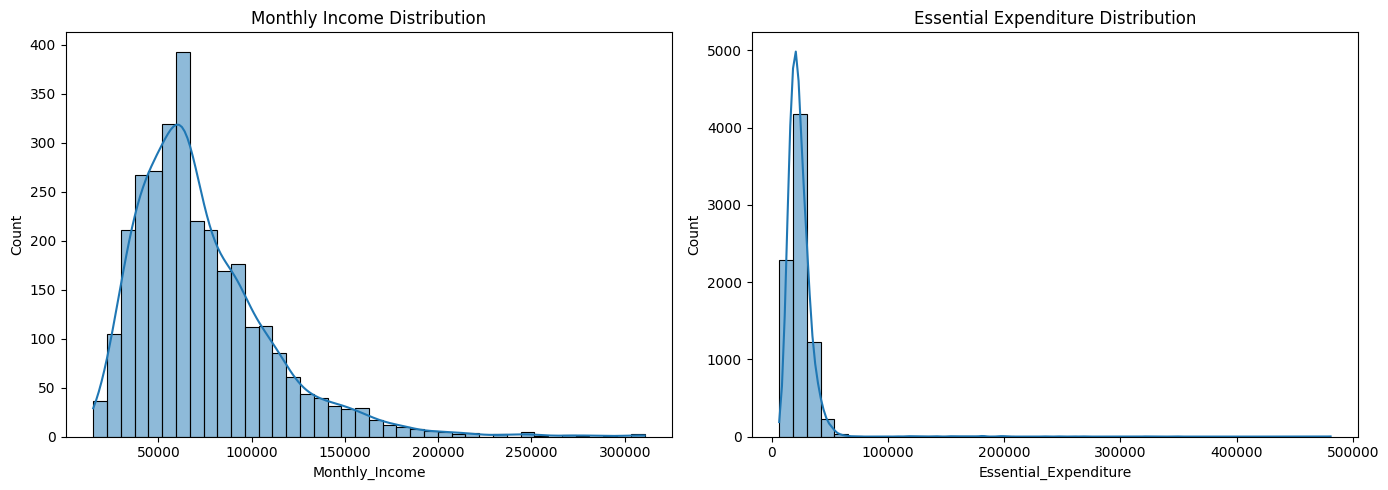

In [24]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.histplot(t1.Monthly_Income,bins=40,kde=True,ax=ax[0])
ax[0].set_title("Monthly Income Distribution")
sns.histplot(t2.Essential_Expenditure,bins=40,kde=True,ax=ax[1])
ax[1].set_title("Essential Expenditure Distribution")
plt.tight_layout()
plt.show()




# GROUP QUESTIONS – 8
1. Is income skewed?
2. Is expenditure skewed?
3. Which variable has stronger evidence of extreme observations?
4. Why is median useful for skewed economic data?


Answer 8
==========================





....
===========================

# 9. CATEGORY EDA

Province counts


,count
Province,
Bagmati,726
Lumbini,535
Madhesh,481
Koshi,411
Gandaki,343
Sudurpashchim,296
Karnali,208


Employment counts


,count
Employment_Status,
Employed,1368
Self-Employed,757
Informal,608
Unemployed,267


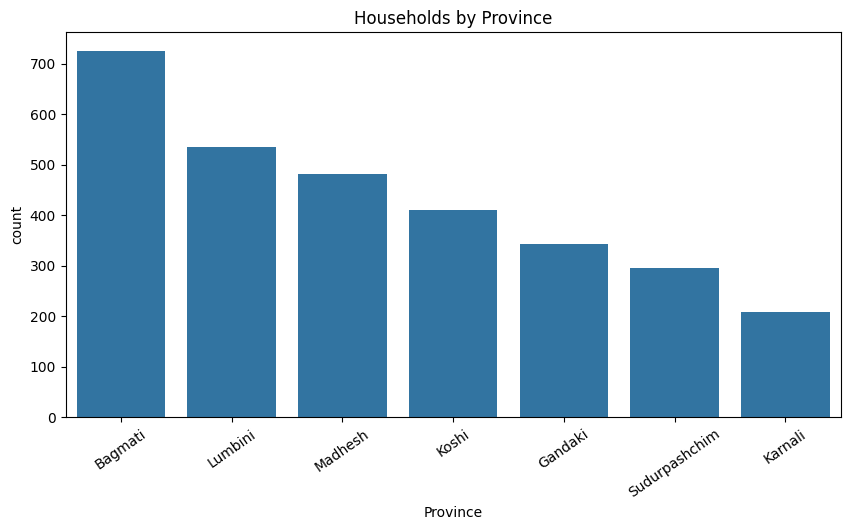

In [26]:
print("Province counts")
display(t1.Province.value_counts())

print("Employment counts")
display(t1.Employment_Status.value_counts())

plt.figure(figsize=(10,5))
sns.countplot(data=t1,x="Province",order=t1.Province.value_counts().index)
plt.title("Households by Province")
plt.xticks(rotation=35)
plt.show()




# GROUP QUESTIONS – 9
1. Which province has the largest sample?
2. Which employment category is largest?
3. Is the dataset balanced across provinces?
4. Why can unequal group sizes affect interpretation?


Answer 9
==========================





....
===========================

# 10. DESCRIPTIVE STATISTICS – MEAN, MEDIAN, MODE

In [27]:
print("TABLE 1 STATISTICS")
display(t1[["Monthly_Income","Household_Size"]].agg(["mean","median","std","min","max"]).T)

print("Income mode:")
display(t1.Monthly_Income.mode())

print("Province mode:")
display(t1.Province.mode())

print("Employment mode:")
display(t1.Employment_Status.mode())

print("\nTABLE 2 STATISTICS")
cols=["Inflation_Rate","Food_Inflation","Interest_Rate",
      "Essential_Expenditure","Discretionary_Expenditure","Employment_Index"]
display(t2[cols].agg(["mean","median","std","min","max"]).T)





TABLE 1 STATISTICS


,mean,median,std,min,max
Monthly_Income,"73,570.30","65,242.50","36,910.20","15,000.00","310,684.00"
Household_Size,4.52,5.00,2.29,1.00,8.00


Income mode:


,Monthly_Income
0,"65,242.50"


Province mode:


,Province
0,Bagmati


Employment mode:


,Employment_Status
0,Employed



TABLE 2 STATISTICS


,mean,median,std,min,max
Inflation_Rate,6.20,6.19,1.11,2.23,10.44
Food_Inflation,7.39,7.39,1.40,2.61,12.26
Interest_Rate,7.49,7.49,0.70,5.11,10.20
Essential_Expenditure,"24,069.35","22,066.50","14,126.98","6,326.00","480,936.00"
Discretionary_Expenditure,"13,256.52","12,022.00","6,174.84","1,986.00","56,636.00"
Employment_Index,92.03,92.07,2.98,79.92,103.36


# GROUP QUESTIONS – 10
1. Compare mean and median income.
2. What does the difference tell you?
3. Which variable has the greatest standard deviation?
4. Which variables are suitable for mode analysis?
5. Why should managers not rely only on average values?


Answer 10
==========================





....
===========================

# 11. SUMMARY / PIVOT ANALYSIS

In [28]:
province_summary=(t1.groupby("Province")
    .agg(Households=("Household_ID","nunique"),
         Avg_Income=("Monthly_Income","mean"),
         Median_Income=("Monthly_Income","median"),
         Avg_Household_Size=("Household_Size","mean"))
    .sort_values("Avg_Income",ascending=False))

display(province_summary)

,Households,Avg_Income,Median_Income,Avg_Household_Size
Province,,,,
Karnali,208,"75,659.23","66,376.00",4.56
Lumbini,535,"75,440.44","65,242.50",4.52
Madhesh,481,"74,344.44","65,242.50",4.46
Koshi,411,"73,343.72","65,242.50",4.65
Gandaki,343,"72,977.61","65,242.50",4.47
Bagmati,726,"72,822.14","65,242.50",4.48
Sudurpashchim,296,"70,300.67","64,092.50",4.61


# GROUP QUESTIONS – 11
1. Which province has the highest average income?
2. Which has the highest median income?
3. Are the rankings identical?
4. Which province has the largest average household size?
5. What management decision could use this summary?


Answer 11
==========================





....
===========================

# 12. MERGE TABLE 1 + TABLE 2

In [29]:
merged=t2.merge(t1,on="Household_ID",how="left",validate="many_to_one")

print("Merged shape:",merged.shape)
display(merged.head())
print("Missing master attributes after merge:")
display(merged[["Province","Area_Type","Employment_Status","Education","Monthly_Income"]].isna().sum())

Merged shape: (7970, 15)


,Household_ID,Observation_Month,Inflation_Rate,Food_Inflation,Interest_Rate,Essential_Expenditure,Discretionary_Expenditure,Employment_Index,Essential_Expenditure_Outlier,Province,Area_Type,Employment_Status,Education,Household_Size,Monthly_Income
0,HH100997,2024-07-01,6.29,6.91,7.34,"20,466.00","7,803.00",90.32,False,Sudurpashchim,Urban,Employed,Master+,3.00,"44,386.00"
1,HH102947,2025-08-01,4.79,8.02,7.64,"16,932.00","10,859.00",91.84,False,Lumbini,Urban,Employed,Secondary,7.00,"174,663.00"
2,HH101637,2024-06-01,4.70,5.25,7.79,"21,352.00","14,162.00",94.33,False,Karnali,Urban,Informal,Bachelor,3.00,"72,398.00"
3,HH102401,2024-02-01,6.55,6.40,8.18,"20,716.00","4,891.00",90.60,False,Lumbini,Rural,Self-Employed,Secondary,6.00,"55,855.00"
4,HH100059,2025-02-01,8.13,6.87,6.79,"22,281.00","23,685.00",92.46,False,Lumbini,Urban,Employed,Secondary,6.00,"39,749.00"


Missing master attributes after merge:


,0
Province,0
Area_Type,0
Employment_Status,0
Education,0
Monthly_Income,0


In [30]:






merged







,Household_ID,Observation_Month,Inflation_Rate,Food_Inflation,Interest_Rate,Essential_Expenditure,Discretionary_Expenditure,Employment_Index,Essential_Expenditure_Outlier,Province,Area_Type,Employment_Status,Education,Household_Size,Monthly_Income
0,HH100997,2024-07-01,6.29,6.91,7.34,"20,466.00","7,803.00",90.32,False,Sudurpashchim,Urban,Employed,Master+,3.00,"44,386.00"
1,HH102947,2025-08-01,4.79,8.02,7.64,"16,932.00","10,859.00",91.84,False,Lumbini,Urban,Employed,Secondary,7.00,"174,663.00"
2,HH101637,2024-06-01,4.70,5.25,7.79,"21,352.00","14,162.00",94.33,False,Karnali,Urban,Informal,Bachelor,3.00,"72,398.00"
3,HH102401,2024-02-01,6.55,6.40,8.18,"20,716.00","4,891.00",90.60,False,Lumbini,Rural,Self-Employed,Secondary,6.00,"55,855.00"
4,HH100059,2025-02-01,8.13,6.87,6.79,"22,281.00","23,685.00",92.46,False,Lumbini,Urban,Employed,Secondary,6.00,"39,749.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7965,HH102224,2024-11-01,4.83,7.78,8.19,"18,525.00","8,388.00",92.05,False,Madhesh,Urban,Employed,Master+,4.00,"85,230.00"
7966,HH102293,2025-09-01,3.85,5.69,8.76,"27,234.00","13,690.00",91.36,False,Koshi,Urban,Informal,Secondary,3.00,"30,498.00"
7967,HH101121,2024-02-01,7.27,7.78,7.26,"17,924.00","12,212.00",92.37,False,Bagmati,Urban,Employed,Bachelor,1.00,"65,454.00"
7968,HH101117,2025-04-01,7.22,6.89,7.68,"13,659.00","12,761.00",93.21,False,Koshi,Rural,Employed,Secondary,7.00,"146,262.00"


In [32]:



from google.colab import sheets
sheet = sheets.InteractiveSheet(df=merged)




https://docs.google.com/spreadsheets/d/1XGpXZ7vjRZo5VRe37FG4DLS41-wDppR07mM2PnVSRl4/edit#gid=0


# GROUP QUESTIONS – 12
1. Why is the merged table larger than 3,000?
2. Explain the one-to-many relationship.
3. Why is `many_to_one` appropriate?
4. What could happen if Household_ID were duplicated in Table 1?
5. Why is merge validation important in MIS?


Answer 12
==========================





....
===========================

# 13. FEATURE ENGINEERING

In [33]:
merged["Total_Expenditure"]=merged.Essential_Expenditure+merged.Discretionary_Expenditure
merged["Discretionary_Share"]=merged.Discretionary_Expenditure/merged.Total_Expenditure
merged["Income_Per_Person"]=merged.Monthly_Income/merged.Household_Size
merged["Savings_Estimate"]=merged.Monthly_Income-merged.Total_Expenditure
merged["Savings_Rate"]=merged.Savings_Estimate/merged.Monthly_Income
merged["Financial_Burden"]=merged.Total_Expenditure/merged.Monthly_Income
merged["Real_Income"]=merged.Monthly_Income/(1+merged.Inflation_Rate/100)

merged["Income_Category"]=pd.qcut(
    merged.Monthly_Income,q=3,labels=["Low Income","Middle Income","High Income"]
)

merged["Economic_Burden_Category"]=pd.cut(
    merged.Financial_Burden,
    bins=[-np.inf,.40,.60,np.inf],
    labels=["Low Burden","Moderate Burden","High Burden"]
)

display(merged[[
    "Household_ID","Monthly_Income","Total_Expenditure",
    "Income_Per_Person","Savings_Estimate","Savings_Rate",
    "Financial_Burden","Real_Income","Income_Category",
    "Economic_Burden_Category"
]].head(10))

,Household_ID,Monthly_Income,Total_Expenditure,Income_Per_Person,Savings_Estimate,Savings_Rate,Financial_Burden,Real_Income,Income_Category,Economic_Burden_Category
0,HH100997,"44,386.00","28,269.00","14,795.33","16,117.00",0.36,0.64,"41,759.34",Low Income,High Burden
1,HH102947,"174,663.00","27,791.00","24,951.86","146,872.00",0.84,0.16,"166,679.07",High Income,Low Burden
2,HH101637,"72,398.00","35,514.00","24,132.67","36,884.00",0.51,0.49,"69,148.04",Middle Income,Moderate Burden
3,HH102401,"55,855.00","25,607.00","9,309.17","30,248.00",0.54,0.46,"52,421.40",Middle Income,Moderate Burden
4,HH100059,"39,749.00","45,966.00","6,624.83","-6,217.00",-0.16,1.16,"36,760.38",Low Income,High Burden
5,HH100033,"29,634.00","30,832.00","7,408.50","-1,198.00",-0.04,1.04,"27,770.59",Low Income,High Burden
6,HH102912,"38,172.00","38,589.00","12,724.00",-417.00,-0.01,1.01,"36,556.22",Low Income,High Burden
7,HH102447,"206,111.00","40,646.00","68,703.67","165,465.00",0.80,0.20,"197,784.28",High Income,Low Burden
8,HH101947,"90,530.00","19,680.00","45,265.00","70,850.00",0.78,0.22,"85,834.83",High Income,Low Burden
9,HH102526,"65,610.00","23,391.00","16,402.50","42,219.00",0.64,0.36,"62,019.09",Middle Income,Low Burden


# GROUP QUESTIONS – 13
Choose five engineered variables.

For each:
1. State the formula/logic.
2. Explain what it measures.
3. Explain why it adds value beyond the original variables.
4. Give one management use.

**Key discussion:** Why can two households with the same income have very different economic conditions?


Answer 13
==========================





....
===========================

# 14. EDA – INCOME VS EXPENDITURE

/tmp/ipykernel_1027/1859326374.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary=(merged.groupby("Income_Category")


,Avg_Income,Avg_Expenditure,Avg_Savings,Avg_Burden
Income_Category,,,,
Low Income,"40,349.30","37,547.58","2,801.72",0.99
Middle Income,"65,974.14","36,844.17","29,129.97",0.57
High Income,"114,955.66","37,585.73","77,369.93",0.35


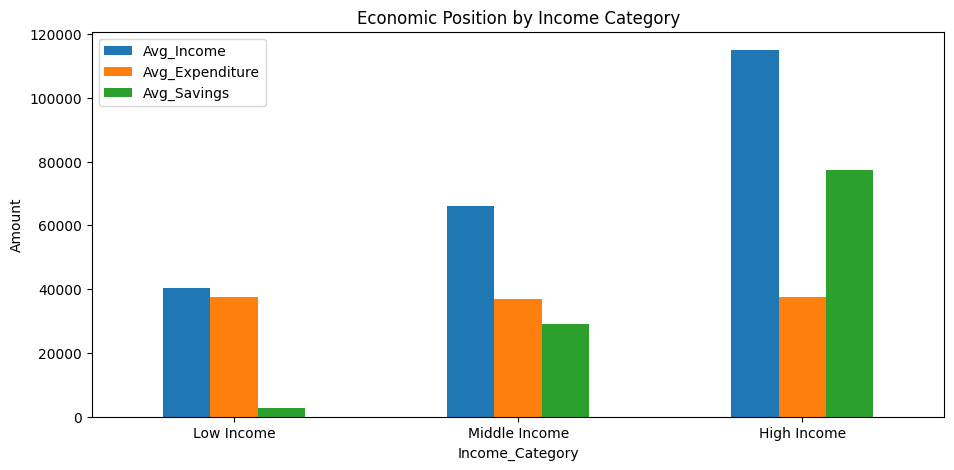

In [34]:
summary=(merged.groupby("Income_Category")
    .agg(Avg_Income=("Monthly_Income","mean"),
         Avg_Expenditure=("Total_Expenditure","mean"),
         Avg_Savings=("Savings_Estimate","mean"),
         Avg_Burden=("Financial_Burden","mean")))

display(summary)

summary[["Avg_Income","Avg_Expenditure","Avg_Savings"]].plot(
    kind="bar",figsize=(11,5)
)
plt.title("Economic Position by Income Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

# GROUP QUESTIONS – 14
1. Which income group spends the most?
2. Which has the highest financial burden?
3. Does higher income automatically mean lower burden?
4. What might explain a high burden?
5. Which group would you monitor if you were a bank/financial manager?


Answer 14
==========================





....
===========================

# 15. MONTHLY ECONOMIC TREND

,Observation_Month,Avg_Inflation,Avg_Food_Inflation,Avg_Interest_Rate,Avg_Expenditure,Avg_Savings,Avg_Burden
0,2024-01-01,6.18,7.42,7.44,"37,096.55","37,006.26",0.64
1,2024-02-01,6.24,7.43,7.51,"37,511.30","35,330.49",0.62
2,2024-03-01,6.24,7.44,7.52,"36,912.06","36,767.77",0.62
3,2024-04-01,6.12,7.51,7.50,"38,524.36","35,415.58",0.68
4,2024-05-01,6.22,7.41,7.55,"36,864.52","37,919.78",0.61


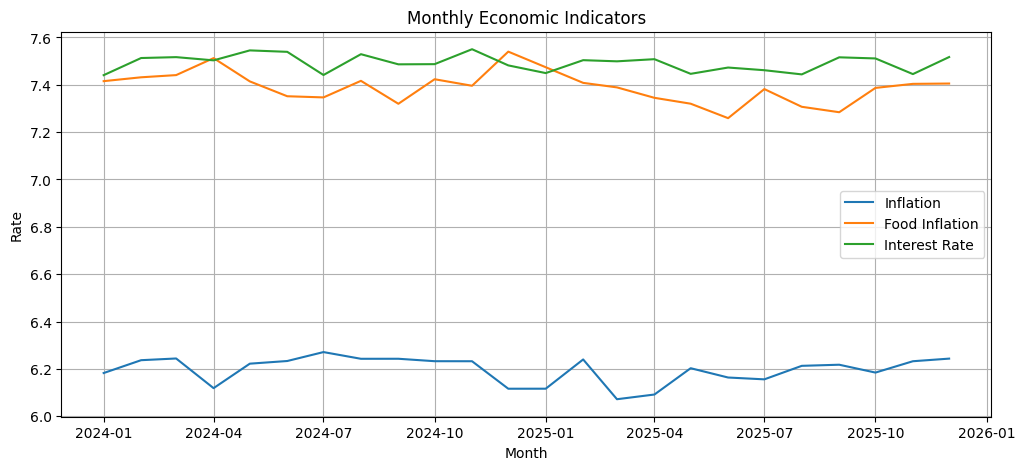

In [35]:
monthly=(merged.groupby("Observation_Month")
    .agg(Avg_Inflation=("Inflation_Rate","mean"),
         Avg_Food_Inflation=("Food_Inflation","mean"),
         Avg_Interest_Rate=("Interest_Rate","mean"),
         Avg_Expenditure=("Total_Expenditure","mean"),
         Avg_Savings=("Savings_Estimate","mean"),
         Avg_Burden=("Financial_Burden","mean"))
    .reset_index())

display(monthly.head())

plt.figure(figsize=(12,5))
plt.plot(monthly.Observation_Month,monthly.Avg_Inflation,label="Inflation")
plt.plot(monthly.Observation_Month,monthly.Avg_Food_Inflation,label="Food Inflation")
plt.plot(monthly.Observation_Month,monthly.Avg_Interest_Rate,label="Interest Rate")
plt.title("Monthly Economic Indicators")
plt.xlabel("Month")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()

# GROUP QUESTIONS – 15
1. What trend do you observe?
2. Does food inflation behave differently from overall inflation?
3. Why should managers monitor inflation and interest rates together?
4. What happens if expenditure rises faster than income?
5. What additional economic variable would improve the analysis?


Answer 15
==========================





....
===========================

# 16. CORRELATION ANALYSIS

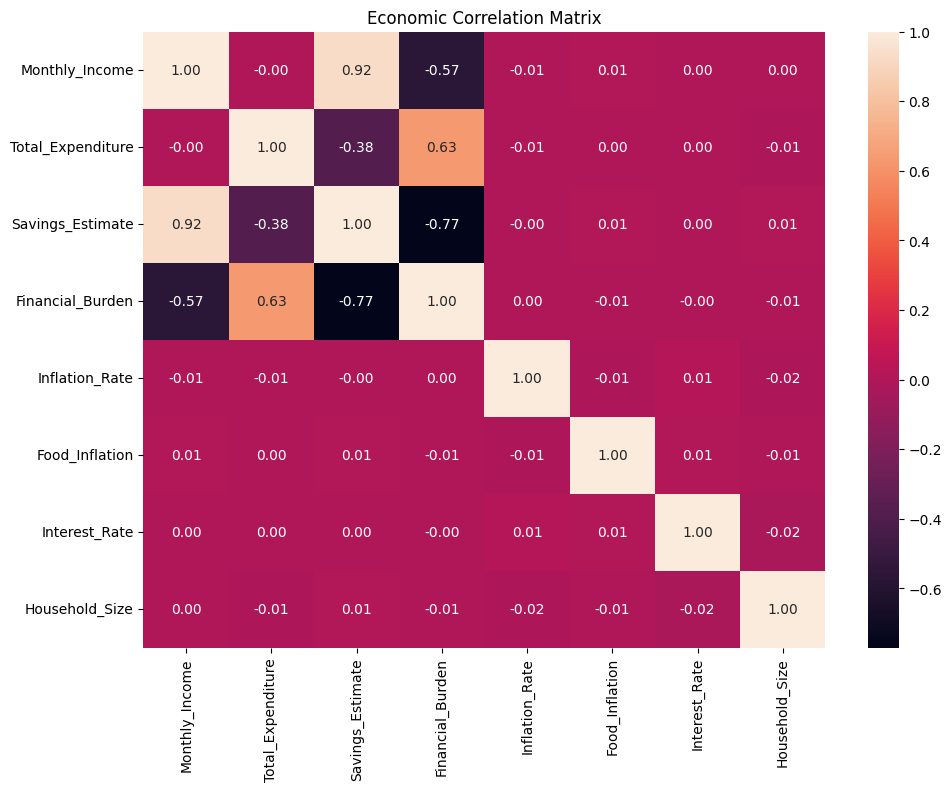

In [36]:
cols=["Monthly_Income","Total_Expenditure","Savings_Estimate",
      "Financial_Burden","Inflation_Rate","Food_Inflation",
      "Interest_Rate","Household_Size"]

corr=merged[cols].corr()
plt.figure(figsize=(11,8))
sns.heatmap(corr,annot=True,fmt=".2f")
plt.title("Economic Correlation Matrix")
plt.show()

# GROUP QUESTIONS – 16
1. Identify two strong relationships.
2. Identify one weak relationship.
3. Which relationship is most useful for management?
4. Why does correlation not prove causation?
5. What other variables could explain the observed relationships?


Answer 16
==========================





....
===========================

# 17. OUTLIER ANALYSIS

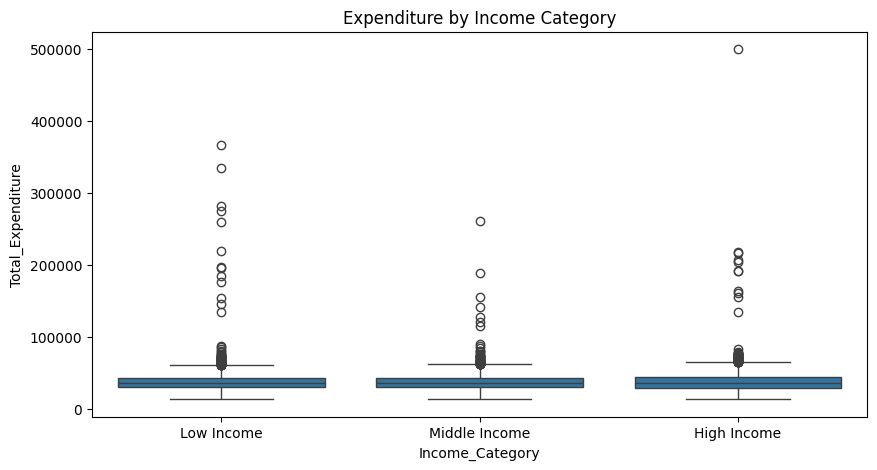

Flagged essential-expenditure outliers: 224


In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(data=merged,x="Income_Category",y="Total_Expenditure")
plt.title("Expenditure by Income Category")
plt.show()

print("Flagged essential-expenditure outliers:",
      merged.Essential_Expenditure_Outlier.sum())

# GROUP QUESTIONS – 17
1. Which income group shows greater expenditure variation?
2. What does the boxplot show that a mean cannot?
3. Should all outliers be deleted?
4. Give one legitimate economic reason for unusually high expenditure.


Answer 17
==========================





....
===========================

# 18. Compare household income distributions across provinces.


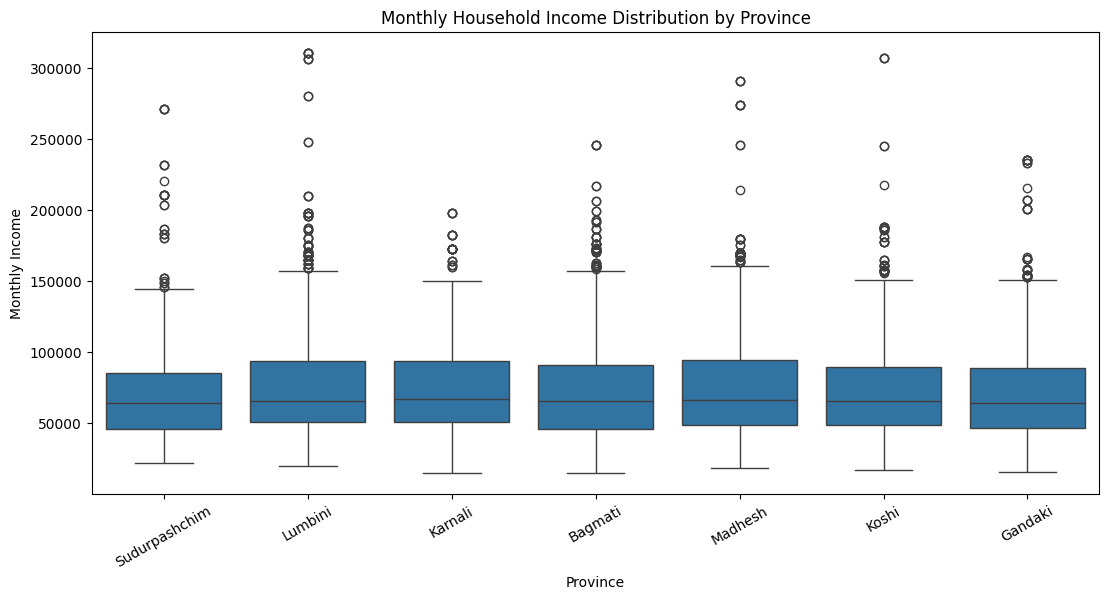

In [42]:



plt.figure(figsize=(13,6))

sns.boxplot(
    data=merged,
    x="Province",
    y="Monthly_Income"
)

plt.title("Monthly Household Income Distribution by Province")
plt.xlabel("Province")
plt.ylabel("Monthly Income")

plt.xticks(rotation=30)
plt.show()



# GROUP QUESTIONS – 18
1. Which province has the highest median household income?

2. Which province shows the greatest income variation?

3. Are there any extreme income values?

4. Why is a boxplot useful for this analysis?

5. Why might average income alone be misleading?

6. What economic factors could explain differences between provinces?



Answer 18
==========================





....
===========================

# 19. URBAN VS RURAL ECONOMIC COMPARISON

,Area_Type,Avg_Income,Avg_Expenditure,Avg_Savings,Avg_Burden
0,Rural,"74,075.00","37,235.15","36,839.85",0.63
1,Urban,"73,498.59","37,392.17","36,106.41",0.64


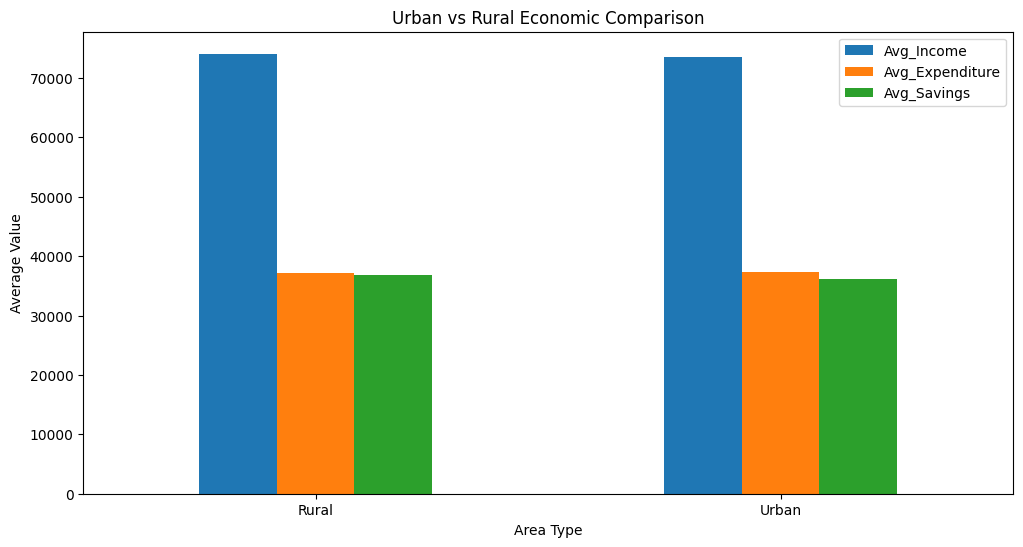

In [48]:

area_summary = merged.groupby("Area_Type").agg(
    Avg_Income=("Monthly_Income", "mean"),
    Avg_Expenditure=("Total_Expenditure", "mean"),
    Avg_Savings=("Savings_Estimate", "mean"),
    Avg_Burden=("Financial_Burden", "mean")
).reset_index()

display(area_summary)

area_summary.plot(
    x="Area_Type",
    y=[
        "Avg_Income",
        "Avg_Expenditure",
        "Avg_Savings"
    ],
    kind="bar",
    figsize=(12,6)
)

plt.title("Urban vs Rural Economic Comparison")
plt.xlabel("Area Type")
plt.ylabel("Average Value")

plt.xticks(rotation=0)
plt.show()


# GROUP QUESTIONS – 19
1. Which area has higher average income?

2. Which area has higher average expenditure?

3. Which area has higher average savings?

4.  Which area has greater financial burden?

5. What economic factors might explain urban-rural differences?



Answer 19
==========================





....
===========================